<a href="https://colab.research.google.com/github/Lekhureddy/ai-project-risk-predictor/blob/main/AI_BASED_PREDICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI-Powered Project Performance Predictor.

Understanding the data.

In [ ]:
# These are like tools from a toolbox - we're getting them ready to use
import pandas as pd          # For working with tables of data
import numpy as np           # For math and number stuff
import matplotlib.pyplot as plt  # For making charts
import seaborn as sns        # For making prettier charts

In [ ]:
# Let's open our data file
from google.colab import drive
drive.mount('/content/drive')
print("📁 Loading your dataset...")

# Read the CSV file (like an Excel spreadsheet)
df = pd.read_csv('/content/drive/MyDrive/updated_report1.csv')

# 'df' is short for DataFrame

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Loading your dataset...


In [ ]:
print("=== LET'S SEE WHAT'S IN OUR DATA ===")
print(f"📊 Rows and columns: {df.shape}")
print(f"   → That's {df.shape[0]} rows and {df.shape[1]} columns")
print(f"📝 Number of columns: {len(df.columns)}")

# Let's count all the individual pieces of data
total_pieces = df.shape[0] * df.shape[1]
print(f"🔢 Total data points: {total_pieces}")

=== LET'S SEE WHAT'S IN OUR DATA ===
📊 Rows and columns: (294, 22)
   → That's 294 rows and 22 columns
📝 Number of columns: 22
🔢 Total data points: 6468


In [ ]:
print("\n=== WHAT ARE OUR COLUMNS CALLED? ===")

# Let's list all column names with numbers
for number, column_name in enumerate(df.columns, 1):
    print(f"  {number:2d}. {column_name}")

# enumerate() gives us both the number (1, 2, 3...) and the column name
# The :2d just makes the numbers line up nicely


=== WHAT ARE OUR COLUMNS CALLED? ===
   1. Product Name
   2. Launch Year
   3. Status
   4. What it does?
   5. Companies
   6. Team Size
   7. Budget Usage (%)
   8. Issues Reported
   9. Risk Level
  10. Outcome
  11. Budget ($K)
  12. Sprint Velocity
  13. Burn-down Score
  14. Adoption
  15. Retention
  16. Churn
  17. Bug Severity Score
  18. Deployment Frequency
  19. OPEX/CAPEX
  20. Forecast Accuracy
  21. Encoded labels
  22. Synthetic correlations


In [ ]:
print("\n=== WHAT TYPE OF DATA DO WE HAVE? ===")
print(df.dtypes)

# dtypes shows if columns have numbers, text, dates, etc.
# Common types:
# - int64: Whole numbers (like 1, 2, 3)
# - float64: Decimal numbers (like 1.5, 2.75)
# - object: Usually text or mix of types


=== WHAT TYPE OF DATA DO WE HAVE? ===
Product Name               object
Launch Year                object
Status                     object
What it does?              object
Companies                  object
Team Size                   int64
Budget Usage (%)          float64
Issues Reported             int64
Risk Level                 object
Outcome                    object
Budget ($K)               float64
Sprint Velocity             int64
Burn-down Score           float64
Adoption                  float64
Retention                   int64
Churn                       int64
Bug Severity Score        float64
Deployment Frequency        int64
OPEX/CAPEX                float64
Forecast Accuracy           int64
Encoded labels              int64
Synthetic correlations      int64
dtype: object


In [ ]:
print("\n=== ANY MISSING DATA? ===")

# Count empty cells in each column
empty_cells = df.isnull().sum()

# Show only columns that have missing data
print("Columns with missing values:")
print(empty_cells[empty_cells > 0])

# If nothing prints, that means no missing data! 🎉


=== ANY MISSING DATA? ===
Columns with missing values:
Budget Usage (%)    1
Outcome             1
Budget ($K)         1
Burn-down Score     1
dtype: int64


In [ ]:
print("\n=== LET'S PEEK AT THE DATA ===")
print("First 3 rows of our table:")
print(df.head(3))

# head(3) shows the first 3 rows
# You can change 3 to 5 or 10 to see more rows


=== LET'S PEEK AT THE DATA ===
First 3 rows of our table:
                Product Name Launch Year  Status  \
0                 Amazon.com        1994  Active   
1               Amazon Prime        2005  Active   
2  Amazon Web Services (AWS)        2006  Active   

                                    What it does? Companies  Team Size  \
0                             E-commerce platform    Amazon          9   
1  Subscription service offering various benefits    Amazon         17   
2                        Cloud computing platform    Amazon         13   

   Budget Usage (%)  Issues Reported Risk Level   Outcome  ...  \
0              57.0                1        Low  Critical  ...   
1             102.0                3        Low  On Track  ...   
2             109.0                8       High  Critical  ...   

   Burn-down Score  Adoption  Retention  Churn  Bug Severity Score  \
0             95.0      68.4         98      2                 1.5   
1             85.0     122.4  

EXPLORATORY DATA ANALYSIS

In [ ]:
#EDA

print("🎯" * 30)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("🎯" * 30)

# Create a nicer display
from IPython.display import display, HTML


🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
EXPLORATORY DATA ANALYSIS (EDA)
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯


In [ ]:
# BASIC INFO ABOUT OUR DATASET
print("\n📊 1. DATASET OVERVIEW")
print("-" * 40)

# Create a summary table
summary_data = {
    "Metric": ["Total Projects", "Total Features", "Total Data Points",
               "Numerical Columns", "Categorical Columns", "Date Columns"],
    "Count": [
        df.shape[0],
        df.shape[1],
        df.shape[0] * df.shape[1],
        len(df.select_dtypes(include=['int64', 'float64']).columns),
        len(df.select_dtypes(include=['object']).columns),
        len(df.select_dtypes(include=['datetime64']).columns)
    ]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)



📊 1. DATASET OVERVIEW
----------------------------------------


,Metric,Count
0,Total Projects,294
1,Total Features,22
2,Total Data Points,6468
3,Numerical Columns,15
4,Categorical Columns,7
5,Date Columns,0



🔍 2. MISSING VALUES ANALYSIS
----------------------------------------
⚠️  Found missing values:


,Missing Values,Percentage
Outcome,1,0.340136
Budget Usage (%),1,0.340136
Budget ($K),1,0.340136
Burn-down Score,1,0.340136


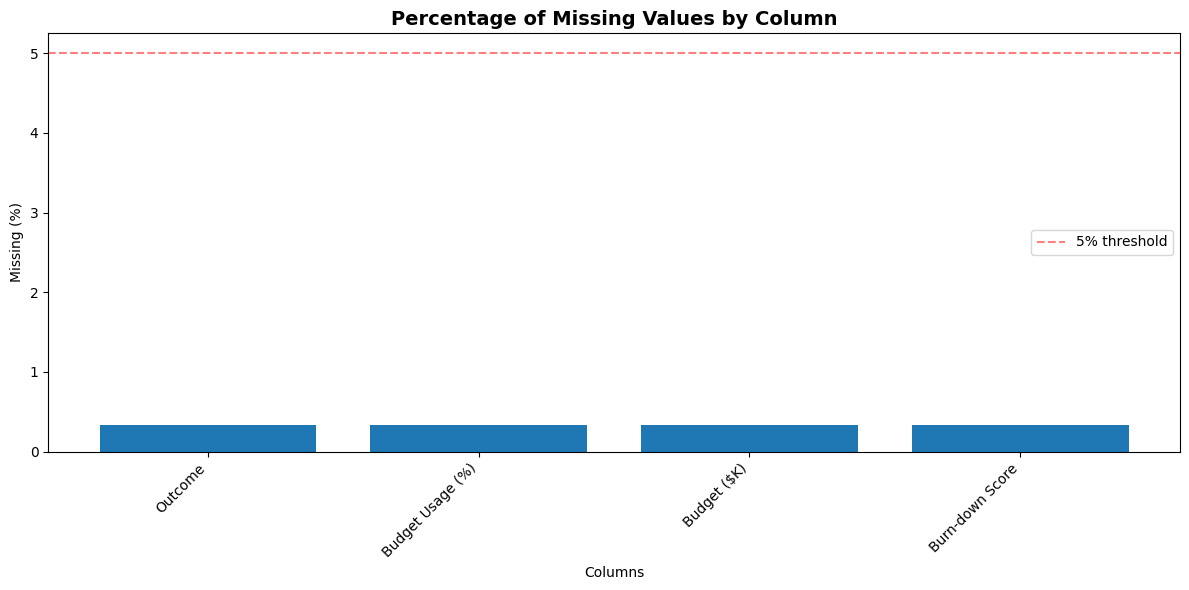

In [ ]:
# CHECK FOR MISSING VALUES VISUALLY
print("\n🔍 2. MISSING VALUES ANALYSIS")
print("-" * 40)

if df.isnull().sum().sum() == 0:
    print("✅ Perfect! No missing values in the dataset!")
else:
    missing_data = df.isnull().sum()
    missing_percentage = (missing_data / len(df)) * 100

    missing_df = pd.DataFrame({
        'Missing Values': missing_data,
        'Percentage': missing_percentage
    }).sort_values('Missing Values', ascending=False)

    # Show only columns with missing values
    missing_df = missing_df[missing_df['Missing Values'] > 0]

    if len(missing_df) > 0:
        print("⚠️  Found missing values:")
        display(missing_df)

        # Visualize missing values
        plt.figure(figsize=(12, 6))
        plt.bar(missing_df.index, missing_df['Percentage'])
        plt.title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
        plt.xlabel('Columns')
        plt.ylabel('Missing (%)')
        plt.xticks(rotation=45, ha='right')
        plt.axhline(y=5, color='r', linestyle='--', alpha=0.5, label='5% threshold')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("✅ No missing values found!")


🎯 3. TARGET VARIABLE ANALYSIS: 'Outcome'
----------------------------------------


,Count,Percentage
Outcome,,
On Track,102,34.693878
Critical,98,33.333333
Delayed,93,31.632653


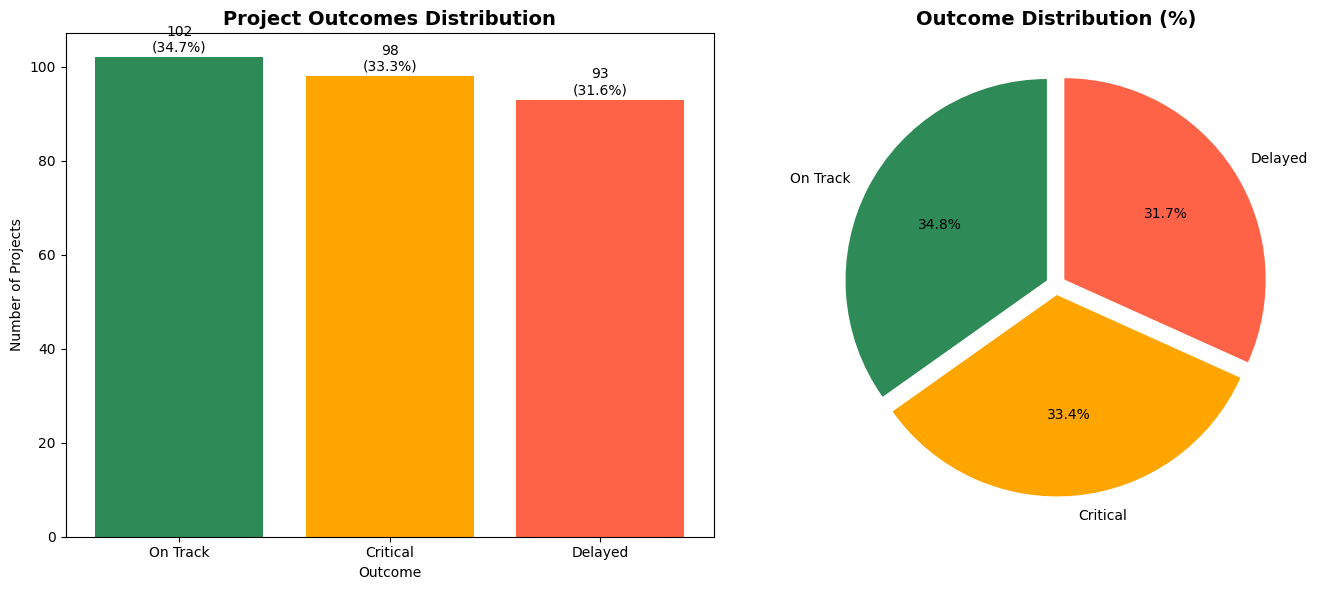

In [ ]:
# UNDERSTAND TARGET VARIABLE (Outcome)
print("\n🎯 3. TARGET VARIABLE ANALYSIS: 'Outcome'")
print("-" * 40)

if 'Outcome' in df.columns:
    outcome_counts = df['Outcome'].value_counts()
    outcome_percent = (outcome_counts / len(df)) * 100

    outcome_summary = pd.DataFrame({
        'Count': outcome_counts,
        'Percentage': outcome_percent
    })

    display(outcome_summary)

    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Bar chart
    colors = ['#2E8B57', '#FFA500', '#FF6347']  # Green, Orange, Red
    bars = ax1.bar(outcome_counts.index, outcome_counts.values, color=colors[:len(outcome_counts)])
    ax1.set_title('Project Outcomes Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Outcome')
    ax1.set_ylabel('Number of Projects')

    # Add counts on bars
    for bar, count in zip(bars, outcome_counts.values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{count}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom')

    # Pie chart
    ax2.pie(outcome_counts.values, labels=outcome_counts.index,
            autopct='%1.1f%%', colors=colors[:len(outcome_counts)],
            startangle=90, explode=[0.05]*len(outcome_counts))
    ax2.set_title('Outcome Distribution (%)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️  'Outcome' column not found in dataset")


In [ ]:
# ANALYZE KEY CATEGORICAL COLUMNS
print("\n🏷️ 4. CATEGORICAL VARIABLES ANALYSIS")
print("-" * 40)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Found {len(categorical_cols)} categorical columns:")

# Remove descriptive columns if present
ignore_cols = ['Product Name', 'What It does?']
analysis_cols = [col for col in categorical_cols if col not in ignore_cols]

# Show top categories for each column
for i, col in enumerate(analysis_cols[:5], 1):  # Limit to first 5 for readability
    print(f"\n{i}. {col}:")
    value_counts = df[col].value_counts()
    print(f"   Unique values: {df[col].nunique()}")
    print(f"   Top 5 values:")
    for val, count in value_counts.head().items():
        percentage = (count / len(df)) * 100
        print(f"     • {val}: {count} projects ({percentage:.1f}%)")


🏷️ 4. CATEGORICAL VARIABLES ANALYSIS
----------------------------------------
Found 7 categorical columns:

1. Launch Year:
   Unique values: 41
   Top 5 values:
     • 2016: 24 projects (8.2%)
     • 2020: 22 projects (7.5%)
     • 2015: 22 projects (7.5%)
     • 2018: 19 projects (6.5%)
     • 2012: 18 projects (6.1%)

2. Status:
   Unique values: 8
   Top 5 values:
     • Active: 275 projects (93.5%)
     • Discontinued: 11 projects (3.7%)
     • Merged with TikTok: 3 projects (1.0%)
     • Active (Limited): 1 projects (0.3%)
     • Active (Beta): 1 projects (0.3%)

3. What it does?:
   Unique values: 244
   Top 5 values:
     • Short-form video app: 6 projects (2.0%)
     • Language translation service: 5 projects (1.7%)
     • Web browser: 5 projects (1.7%)
     • News aggregator: 4 projects (1.4%)
     • Cloud storage service: 4 projects (1.4%)

4. Companies:
   Unique values: 9
   Top 5 values:
     • Yandex: 40 projects (13.6%)
     • Apple: 37 projects (12.6%)
     • Amazon: 


🔢 5. NUMERICAL VARIABLES ANALYSIS
----------------------------------------
Found 15 numerical columns:

📋 Basic Statistics:


,count,mean,std,min,25%,50%,75%,max,missing
Team Size,294.0,10.517007,5.161360,3.0,6.0,10.0,15.0,19.0,0
Budget Usage (%),293.0,83.945392,20.482797,50.0,66.0,83.0,102.0,119.0,1
Issues Reported,294.0,7.034014,4.384140,0.0,3.0,7.0,11.0,14.0,0
Budget ($K),293.0,2441.911263,1413.547184,101.0,1116.0,2355.0,3691.0,4989.0,1
Sprint Velocity,294.0,105.170068,51.613604,30.0,60.0,100.0,150.0,190.0,0
Burn-down Score,293.0,64.726962,21.886863,30.0,45.0,65.0,85.0,100.0,1
Adoption,294.0,100.779592,24.549569,60.0,79.2,99.6,122.4,142.8,0
Retention,294.0,85.931973,8.768280,72.0,78.0,86.0,94.0,100.0,0
Churn,294.0,14.068027,8.768280,0.0,6.0,14.0,22.0,28.0,0
Bug Severity Score,294.0,10.551020,6.576210,0.0,4.5,10.5,16.5,21.0,0



📊 Distribution of Key Numerical Features:


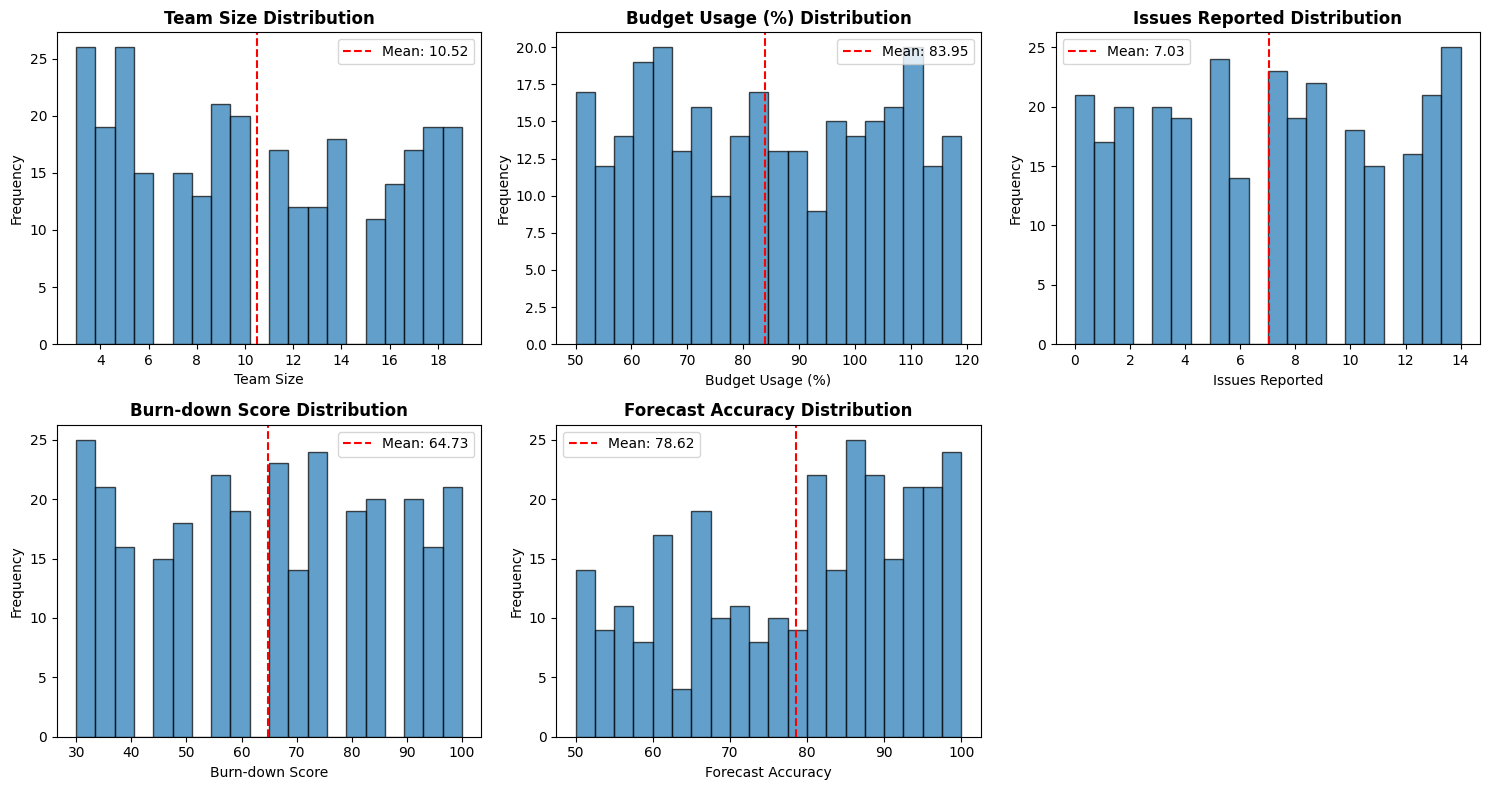

In [ ]:
# NUMERICAL VARIABLES ANALYSIS
print("\n🔢 5. NUMERICAL VARIABLES ANALYSIS")
print("-" * 40)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Found {len(numerical_cols)} numerical columns:")

# Show basic statistics
if len(numerical_cols) > 0:
    # Display basic stats
    print("\n📋 Basic Statistics:")
    stats_df = df[numerical_cols].describe().T
    stats_df['missing'] = df[numerical_cols].isnull().sum()
    display(stats_df.head(10))  # Show first 10 for readability

    # Create distribution plots for key numerical columns
    key_numerical = ['Team Size', 'Budget Usage (%)', 'Issues Reported',
                     'Burn-down Score', 'Forecast Accuracy']
    key_numerical = [col for col in key_numerical if col in df.columns]

    if key_numerical:
        print(f"\n📊 Distribution of Key Numerical Features:")

        # Create subplots
        n_cols = min(3, len(key_numerical))
        n_rows = (len(key_numerical) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
        axes = axes.flatten() if n_rows > 1 else [axes]

        for idx, col in enumerate(key_numerical):
            if idx < len(axes):
                axes[idx].hist(df[col].dropna(), bins=20, edgecolor='black', alpha=0.7)
                axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Frequency')

                # Add mean line
                mean_val = df[col].mean()
                axes[idx].axvline(mean_val, color='red', linestyle='--',
                                 label=f'Mean: {mean_val:.2f}')
                axes[idx].legend()

        # Hide empty subplots
        for idx in range(len(key_numerical), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()



📈 6. CORRELATION ANALYSIS
----------------------------------------


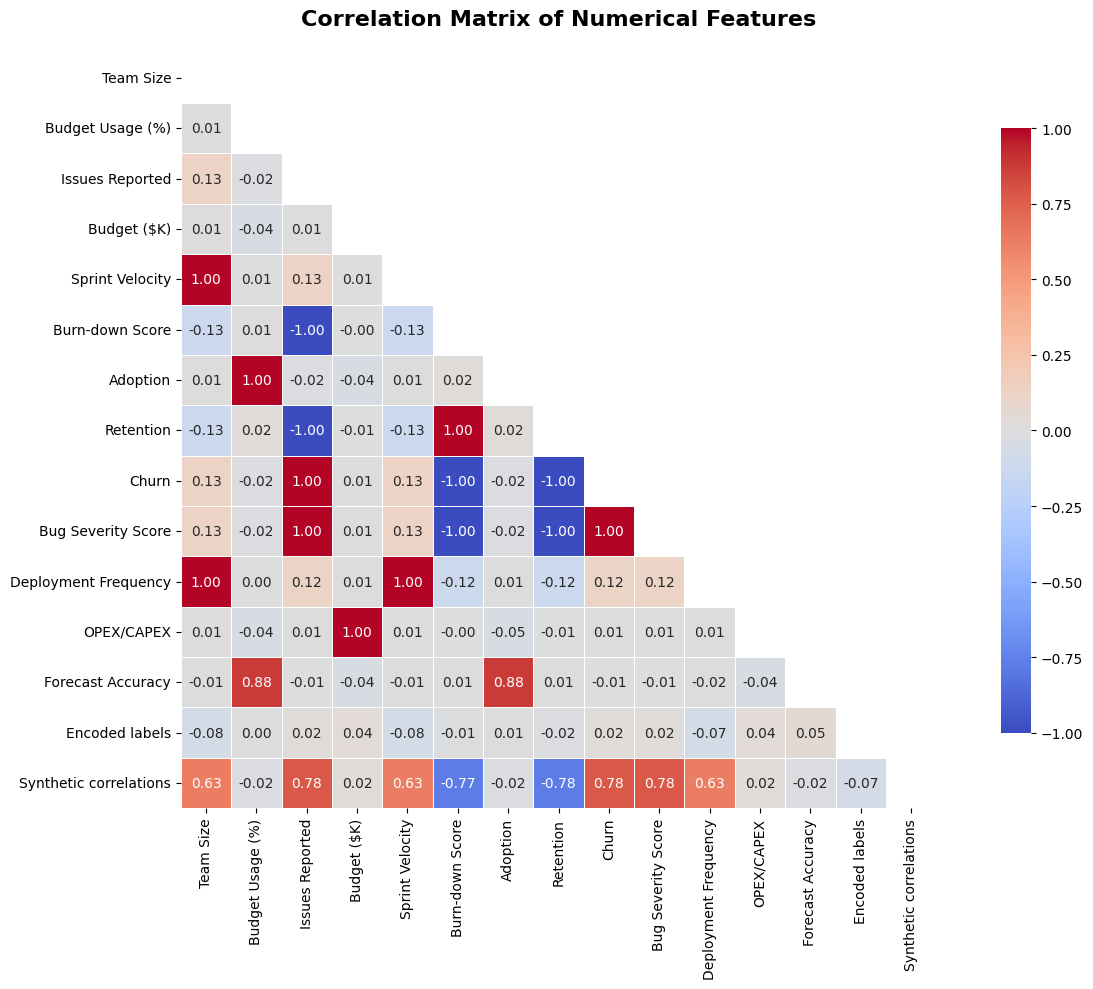


🔍 Strongest Correlations (|r| > 0.5):


,Feature 1,Feature 2,Correlation
0,Team Size,Sprint Velocity,1.000000
3,Budget Usage (%),Adoption,1.000000
19,Retention,Bug Severity Score,-1.000000
13,Burn-down Score,Retention,1.000000
14,Burn-down Score,Churn,-1.000000
15,Burn-down Score,Bug Severity Score,-1.000000
5,Issues Reported,Burn-down Score,-1.000000
6,Issues Reported,Retention,-1.000000
18,Retention,Churn,-1.000000
7,Issues Reported,Churn,1.000000


In [ ]:
# CORRELATION ANALYSIS
print("\n📈 6. CORRELATION ANALYSIS")
print("-" * 40)

if len(numerical_cols) > 1:
    # Calculate correlation matrix
    corr_matrix = df[numerical_cols].corr()

    # Plot heatmap
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True,
                linewidths=0.5, cbar_kws={"shrink": 0.8})

    plt.title('Correlation Matrix of Numerical Features',
              fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # Find strongest correlations
    print("\n🔍 Strongest Correlations (|r| > 0.5):")
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.5:
                strong_corrs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_value
                })

    if strong_corrs:
        strong_corr_df = pd.DataFrame(strong_corrs)
        display(strong_corr_df.sort_values('Correlation', key=abs, ascending=False))
    else:
        print("No strong correlations found (all |r| < 0.5)")
else:
    print("Need at least 2 numerical columns for correlation analysis")


🔗 7. RELATIONSHIPS BETWEEN KEY VARIABLES
----------------------------------------


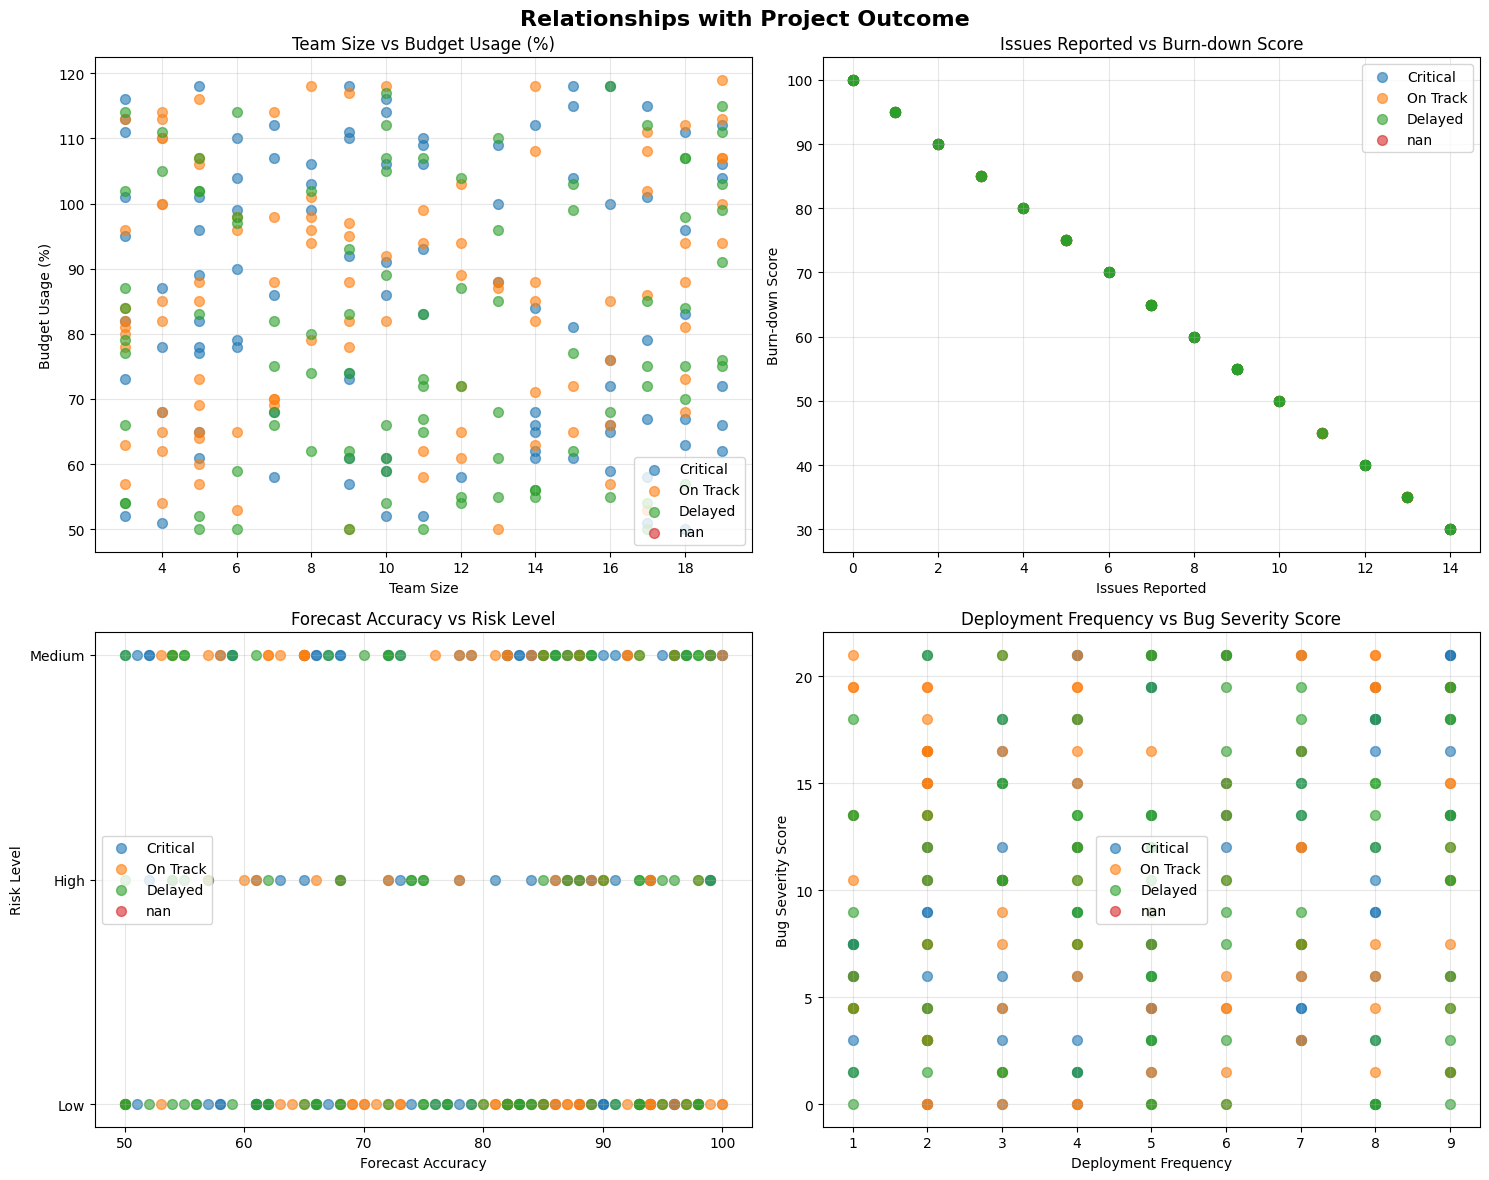

In [ ]:
# RELATIONSHIP BETWEEN KEY VARIABLES
print("\n🔗 7. RELATIONSHIPS BETWEEN KEY VARIABLES")
print("-" * 40)

# Scatter plots for important relationships
if 'Outcome' in df.columns:
    # Set up plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Relationships with Project Outcome', fontsize=16, fontweight='bold')

    plots_to_make = [
        ('Team Size', 'Budget Usage (%)'),
        ('Issues Reported', 'Burn-down Score'),
        ('Forecast Accuracy', 'Risk Level'),
        ('Deployment Frequency', 'Bug Severity Score')
    ]

    for idx, (x_col, y_col) in enumerate(plots_to_make):
        if x_col in df.columns and y_col in df.columns:
            ax = axes[idx//2, idx%2]

            # Create scatter plot colored by Outcome
            for outcome in df['Outcome'].unique():
                subset = df[df['Outcome'] == outcome]
                ax.scatter(subset[x_col], subset[y_col],
                          label=outcome, alpha=0.6, s=50)

            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            ax.set_title(f'{x_col} vs {y_col}')
            ax.legend()
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


📊 8. HOW VARIABLES DIFFER BY OUTCOME
----------------------------------------


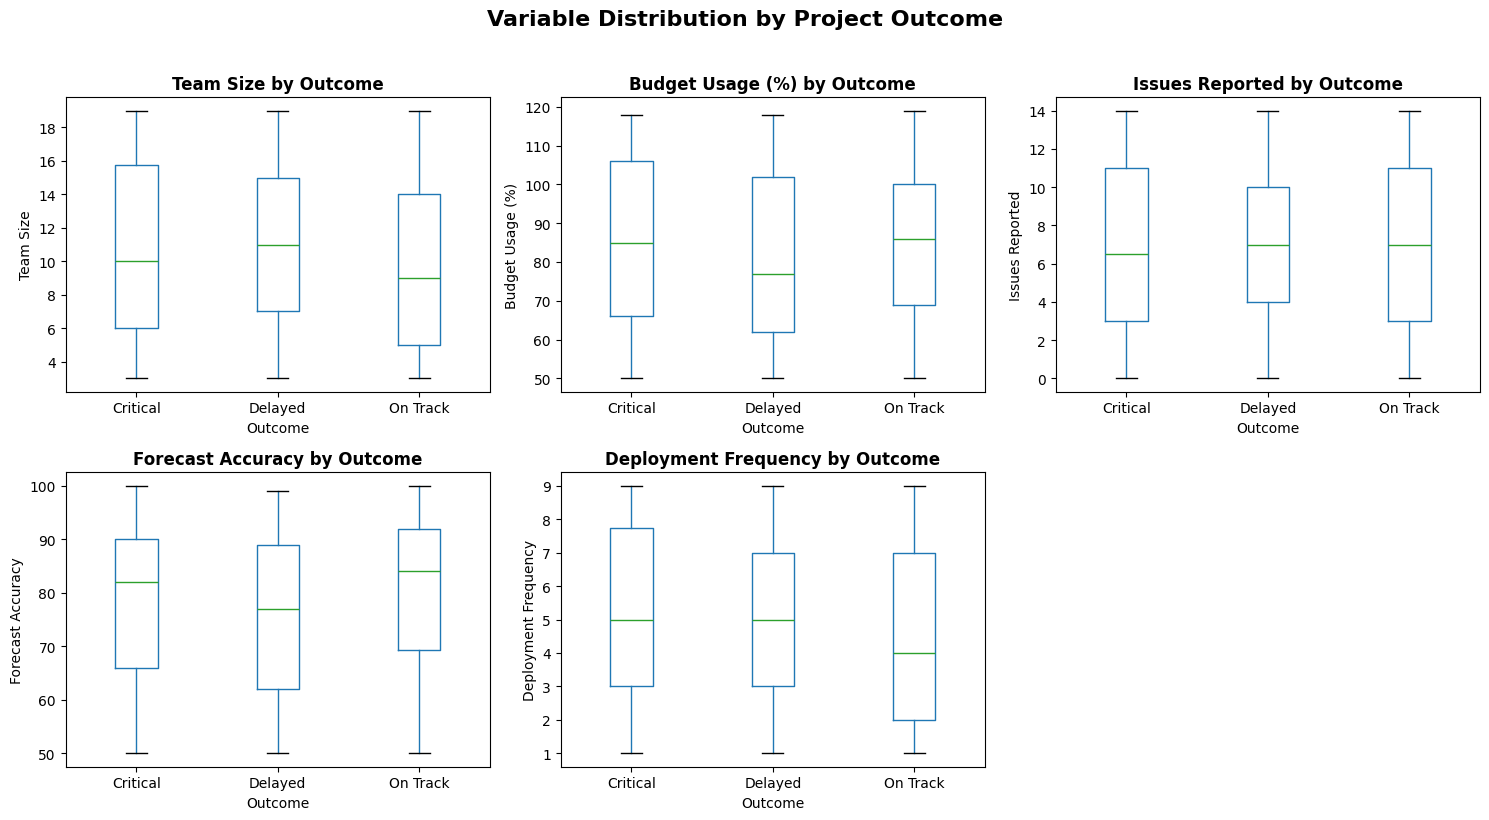

In [ ]:
# UNIVARIATE ANALYSIS BY OUTCOME
print("\n📊 8. HOW VARIABLES DIFFER BY OUTCOME")
print("-" * 40)

if 'Outcome' in df.columns:
    # Select a few key variables to analyze
    analysis_vars = ['Team Size', 'Budget Usage (%)', 'Issues Reported',
                     'Forecast Accuracy', 'Deployment Frequency']
    analysis_vars = [var for var in analysis_vars if var in df.columns]

    if analysis_vars:
        # Create box plots
        n_cols = min(3, len(analysis_vars))
        n_rows = (len(analysis_vars) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
        axes = axes.flatten() if n_rows > 1 else [axes]

        for idx, var in enumerate(analysis_vars):
            if idx < len(axes):
                # Create boxplot
                df.boxplot(column=var, by='Outcome', ax=axes[idx], grid=False)
                axes[idx].set_title(f'{var} by Outcome', fontsize=12, fontweight='bold')
                axes[idx].set_xlabel('Outcome')
                axes[idx].set_ylabel(var)

                # Remove default title
                axes[idx].get_figure().suptitle('')

        # Hide empty subplots
        for idx in range(len(analysis_vars), len(axes)):
            axes[idx].set_visible(False)

        plt.suptitle('Variable Distribution by Project Outcome',
                     fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

In [ ]:
# SUMMARY INSIGHTS
print("\n💡 9. KEY INSIGHTS & OBSERVATIONS")
print("-" * 40)

insights = []

# Insight 1: Data quality
if df.isnull().sum().sum() == 0:
    insights.append("✅ **Data Quality**: No missing values - excellent data quality!")

# Insight 2: Class balance
if 'Outcome' in df.columns:
    outcome_dist = df['Outcome'].value_counts(normalize=True)
    if outcome_dist.max() < 0.7:  # No class dominates
        insights.append("✅ **Class Balance**: Outcome classes are reasonably balanced")
    else:
        dominant_class = outcome_dist.idxmax()
        insights.append(f"⚠️ **Class Imbalance**: '{dominant_class}' dominates ({outcome_dist.max():.1%})")

# Insight 3: Risk vs Outcome
if 'Risk Level' in df.columns and 'Outcome' in df.columns:
    risk_outcome = pd.crosstab(df['Risk Level'], df['Outcome'], normalize='index')
    insights.append("📊 **Risk Impact**: Check risk_outcome table below for risk-outcome relationship")
    display(risk_outcome.style.background_gradient(cmap='Blues'))

# Insight 4: Strong correlations
if 'strong_corr_df' in locals() and len(strong_corr_df) > 0:
    top_corr = strong_corr_df.iloc[0]
    insights.append(f"🔗 **Strong Correlation**: {top_corr['Feature 1']} and {top_corr['Feature 2']} "
                   f"are strongly correlated (r = {top_corr['Correlation']:.2f})")

# Display all insights
print("\n".join(insights) if insights else "No specific insights generated")

print("\n" + "="*60)
print("🎉 EDA COMPLETE! NEXT STEPS:")
print("="*60)
print("1. Based on insights, decide what to predict")
print("2. Prepare data for machine learning")
print("="*60)


💡 9. KEY INSIGHTS & OBSERVATIONS
----------------------------------------


Outcome,Critical,Delayed,On Track
Risk Level,,,
High,0.344828,0.362069,0.293103
Low,0.259259,0.340741,0.400000
Medium,0.430000,0.260000,0.310000


✅ **Class Balance**: Outcome classes are reasonably balanced
📊 **Risk Impact**: Check risk_outcome table below for risk-outcome relationship
🔗 **Strong Correlation**: Team Size and Sprint Velocity are strongly correlated (r = 1.00)

🎉 EDA COMPLETE! NEXT STEPS:
1. Based on insights, decide what to predict
2. Prepare data for machine learning


DATA PREPARATION FOR MACHINE LEARNING

In [ ]:
print("🔧" * 30)
print("DATA PREPARATION FOR MACHINE LEARNING")
print("🔧" * 30)

# DECIDE WHAT TO PREDICT
print("\n🎯 1. CHOOSING OUR PREDICTION TASK")
print("-" * 40)

print("Based on EDA, we have several prediction options:")
print("1. Classification: Predict 'Outcome' (Critical/Delayed/On Track)")
print("2. Classification: Predict 'Risk Level' (High/Medium/Low)")
print("3. Regression: Predict 'Budget Usage (%)'")
print("4. Regression: Predict 'Forecast Accuracy'")

# Let's choose Outcome prediction as our main task
print("\n✅ SELECTED: Predicting 'Outcome' (Multi-class Classification)")
print("   Why? This is most valuable for project managers!")

🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧
DATA PREPARATION FOR MACHINE LEARNING
🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧🔧

🎯 1. CHOOSING OUR PREDICTION TASK
----------------------------------------
Based on EDA, we have several prediction options:
1. Classification: Predict 'Outcome' (Critical/Delayed/On Track)
2. Classification: Predict 'Risk Level' (High/Medium/Low)
3. Regression: Predict 'Budget Usage (%)'
4. Regression: Predict 'Forecast Accuracy'

✅ SELECTED: Predicting 'Outcome' (Multi-class Classification)
   Why? This is most valuable for project managers!


In [ ]:
# FEATURE SELECTION
print("\n🔍 2. SELECTING AND ENGINEERING FEATURES")
print("-" * 40)

# Identify all potential features
print("Available features in dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

# Separate target and features
target = 'Outcome'

# Remove columns that won't be useful for prediction
# (like IDs, text descriptions, etc.)
columns_to_drop = ['Product Name', 'What It does?', 'Companies']  # These are identifiers/text
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

print(f"\nRemoving non-predictive columns: {columns_to_drop}")

# Create feature set
X = df.drop(columns=[target] + columns_to_drop)
y = df[target]

print(f"\n✅ Final feature set: {X.shape[1]} features")
print(f"✅ Target variable: {target} ({y.nunique()} classes)")

# Show selected features
print("\nSelected features for modeling:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")


🔍 2. SELECTING AND ENGINEERING FEATURES
----------------------------------------
Available features in dataset:
   1. Product Name
   2. Launch Year
   3. Status
   4. What it does?
   5. Companies
   6. Team Size
   7. Budget Usage (%)
   8. Issues Reported
   9. Risk Level
  10. Outcome
  11. Budget ($K)
  12. Sprint Velocity
  13. Burn-down Score
  14. Adoption
  15. Retention
  16. Churn
  17. Bug Severity Score
  18. Deployment Frequency
  19. OPEX/CAPEX
  20. Forecast Accuracy
  21. Encoded labels
  22. Synthetic correlations

Removing non-predictive columns: ['Product Name', 'Companies']

✅ Final feature set: 19 features
✅ Target variable: Outcome (3 classes)

Selected features for modeling:
   1. Launch Year
   2. Status
   3. What it does?
   4. Team Size
   5. Budget Usage (%)
   6. Issues Reported
   7. Risk Level
   8. Budget ($K)
   9. Sprint Velocity
  10. Burn-down Score
  11. Adoption
  12. Retention
  13. Churn
  14. Bug Severity Score
  15. Deployment Frequency
  16.

In [ ]:
# HANDLE CATEGORICAL VARIABLES
print("\n🔤 3. ENCODING CATEGORICAL VARIABLES")
print("-" * 40)

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

if categorical_cols:
    # One-hot encode categorical variables
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print(f"✅ After encoding: {X_encoded.shape[1]} features")

    # Show new column names
    print("\nFirst 10 encoded feature names:")
    for col in X_encoded.columns[:10]:
        print(f"  • {col}")
else:
    X_encoded = X.copy()
    print("✅ No categorical columns to encode")


🔤 3. ENCODING CATEGORICAL VARIABLES
----------------------------------------
Categorical columns to encode: ['Launch Year', 'Status', 'What it does?', 'Risk Level']
✅ After encoding: 307 features

First 10 encoded feature names:
  • Team Size
  • Budget Usage (%)
  • Issues Reported
  • Budget ($K)
  • Sprint Velocity
  • Burn-down Score
  • Adoption
  • Retention
  • Churn
  • Bug Severity Score


In [ ]:

# Define target
target = "Outcome"

# Columns that MUST NOT go into the model
drop_cols = [
    "Product Name",
    "What it does?",
    "Companies",
    "Encoded labels",
    "Synthetic correlations",
    target
]

# Keep only columns that actually exist
drop_cols = [c for c in drop_cols if c in df.columns]

# Split X and y
X = df.drop(columns=drop_cols)
y = df[target]

# Remove rows with missing target
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Handle missing values
num_cols = X_encoded.select_dtypes(include=[np.number]).columns
X_encoded[num_cols] = X_encoded[num_cols].fillna(X_encoded[num_cols].median())
X_encoded = X_encoded.fillna(0)

print("✅ Clean X shape:", X_encoded.shape)
print("✅ Target values:", y.unique())
print("✅ Total NaNs:", X_encoded.isna().sum().sum())


✅ Clean X shape: (293, 62)
✅ Target values: ['Critical' 'On Track' 'Delayed']
✅ Total NaNs: 0


In [ ]:
rf_model.feature_names_in_


array(['Team Size', 'Budget Usage (%)', 'Issues Reported', 'Budget ($K)',
       'Sprint Velocity', 'Burn-down Score', 'Adoption', 'Retention',
       'Churn', 'Bug Severity Score', 'Deployment Frequency',
       'OPEX/CAPEX', 'Forecast Accuracy', 'Launch Year_1982',
       'Launch Year_1984', 'Launch Year_1985', 'Launch Year_1989',
       'Launch Year_1990', 'Launch Year_1992', 'Launch Year_1993',
       'Launch Year_1994', 'Launch Year_1995', 'Launch Year_1997',
       'Launch Year_1998', 'Launch Year_1999', 'Launch Year_2000',
       'Launch Year_2001', 'Launch Year_2002', 'Launch Year_2003',
       'Launch Year_2004', 'Launch Year_2005', 'Launch Year_2006',
       'Launch Year_2006 (as Google Apps)', 'Launch Year_2007',
       'Launch Year_2008', 'Launch Year_2009', 'Launch Year_2010',
       'Launch Year_2011', 'Launch Year_2011 (as Google Wallet)',
       'Launch Year_2011 (as Nest Labs)', 'Launch Year_2012',
       'Launch Year_2013', 'Launch Year_2014', 'Launch Year_2015',
    

In [ ]:
# 1) If y has NaN, drop those rows (must keep X and y aligned)
mask = y.notna()
X_encoded = X_encoded.loc[mask].copy()
y = y.loc[mask].copy()

# 2) Fill missing values in X_encoded
num_cols = X_encoded.select_dtypes(include=[np.number]).columns
X_encoded[num_cols] = X_encoded[num_cols].fillna(X_encoded[num_cols].median())

# Fill any remaining NaNs (categorical leftovers)
X_encoded = X_encoded.fillna(X_encoded.mode().iloc[0]).fillna(0)

print("✅ NaNs in X_encoded:", X_encoded.isna().sum().sum())
print("✅ NaNs in y:", y.isna().sum())


# SPLIT DATA FOR TRAINING AND TESTING
print("\n✂️ 4. SPLITTING DATA INTO TRAIN/TEST SETS")
print("-" * 40)

from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

# Check class distribution
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))

print("\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True).round(3))

✅ NaNs in X_encoded: 0
✅ NaNs in y: 0

✂️ 4. SPLITTING DATA INTO TRAIN/TEST SETS
----------------------------------------
Training set size: 234 samples
Testing set size: 59 samples
Number of features: 62

Class distribution in training set:
Outcome
On Track    0.350
Critical    0.333
Delayed     0.316
Name: proportion, dtype: float64

Class distribution in testing set:
Outcome
Critical    0.339
On Track    0.339
Delayed     0.322
Name: proportion, dtype: float64


In [ ]:

print("BUILDING MACHINE LEARNING MODELS")


# Import ML libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. RANDOM FOREST MODEL
print("\n🌲 1. TRAINING RANDOM FOREST CLASSIFIER")
print("-" * 40)

# Create and train model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"✅ Random Forest Accuracy: {rf_accuracy:.2%}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 2. LOGISTIC REGRESSION MODEL
print("\n📈 2. TRAINING LOGISTIC REGRESSION")
print("-" * 40)

# Create and train model
lr_model = LogisticRegression(random_state=42, max_iter=2000)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"✅ Logistic Regression Accuracy: {lr_accuracy:.2%}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Compare models
print("\n🏆 MODEL COMPARISON")
print("-" * 40)
print(f"Random Forest Accuracy:     {rf_accuracy:.2%}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

if rf_accuracy > lr_accuracy:
    print(f"\n🎯 Winner: Random Forest (by {(rf_accuracy - lr_accuracy):.2%})")
else:
    print(f"\n🎯 Winner: Logistic Regression (by {(lr_accuracy - rf_accuracy):.2%})")

BUILDING MACHINE LEARNING MODELS

🌲 1. TRAINING RANDOM FOREST CLASSIFIER
----------------------------------------
✅ Random Forest Accuracy: 30.51%

📊 Classification Report:
              precision    recall  f1-score   support

    Critical       0.26      0.25      0.26        20
     Delayed       0.29      0.26      0.28        19
    On Track       0.35      0.40      0.37        20

    accuracy                           0.31        59
   macro avg       0.30      0.30      0.30        59
weighted avg       0.30      0.31      0.30        59


📈 2. TRAINING LOGISTIC REGRESSION
----------------------------------------
✅ Logistic Regression Accuracy: 23.73%

📊 Classification Report:
              precision    recall  f1-score   support

    Critical       0.21      0.15      0.18        20
     Delayed       0.28      0.37      0.32        19
    On Track       0.20      0.20      0.20        20

    accuracy                           0.24        59
   macro avg       0.23      0.24

In [ ]:
print("\n🧮 3. GENERATE PREDICTIONS + RISK SCORE (for Jira)")
print("-" * 40)

# Use Random Forest as main model (better than LR in your result)
proba = rf_model.predict_proba(X_test)

# classes order (important)
classes = rf_model.classes_
print("Classes order:", classes)

# Predicted outcome already computed: y_pred_rf
# Risk score idea: probability of NOT "On Track"
# RiskScore = 100 * (1 - P(On Track))

if "On Track" in classes:
    ontrack_idx = list(classes).index("On Track")
    risk_score = (1 - proba[:, ontrack_idx]) * 100
else:
    # fallback: risk score = max probability * 100
    risk_score = proba.max(axis=1) * 100

pred_df = pd.DataFrame({
    "Actual Outcome": y_test.values,
    "Predicted Outcome": y_pred_rf,
    "Risk Score": risk_score.round(2)
})

print(pred_df.head(10))
print("\nRisk score summary:")
print(pred_df["Risk Score"].describe())



🧮 3. GENERATE PREDICTIONS + RISK SCORE (for Jira)
----------------------------------------
Classes order: ['Critical' 'Delayed' 'On Track']
  Actual Outcome Predicted Outcome  Risk Score
0        Delayed          Critical        79.5
1       Critical          On Track        59.0
2       Critical          On Track        52.5
3       Critical          On Track        55.5
4       Critical          On Track        57.5
5       Critical          Critical        68.5
6       On Track           Delayed        76.0
7       Critical          Critical        77.5
8       On Track          On Track        60.5
9       Critical          Critical        85.0

Risk score summary:
count    59.000000
mean     64.271186
std      11.780069
min      30.000000
25%      56.750000
50%      65.500000
75%      73.000000
max      85.000000
Name: Risk Score, dtype: float64


In [ ]:
pred_df.to_csv("jira_predictions_output.csv", index=False)
print("✅ Saved file: jira_predictions_output.csv")


✅ Saved file: jira_predictions_output.csv


In [ ]:
# SIMPLEST CSV FOR JIRA (NO CONFUSION)

easy_jira_df = pd.DataFrame({
    "Row ID": range(1, len(full_pred) + 1),
    "Predicted Outcome": full_pred,
    "Risk Score": full_risk_score.round(0)  # whole numbers look cleaner in Jira
})

print(easy_jira_df.head(10))

easy_jira_df.to_csv("jira_easy_upload.csv", index=False)
print("✅ Saved: jira_easy_upload.csv")


   Row ID Predicted Outcome  Risk Score
0       1          Critical        92.0
1       2          Critical        72.0
2       3          Critical        85.0
3       4           Delayed        96.0
4       5          Critical        70.0
5       6           Delayed        92.0
6       7           Delayed        86.0
7       8          On Track        55.0
8       9           Delayed        82.0
9      10          Critical        84.0
✅ Saved: jira_easy_upload.csv



📊 3. MODEL PERFORMANCE VISUALIZATION
----------------------------------------


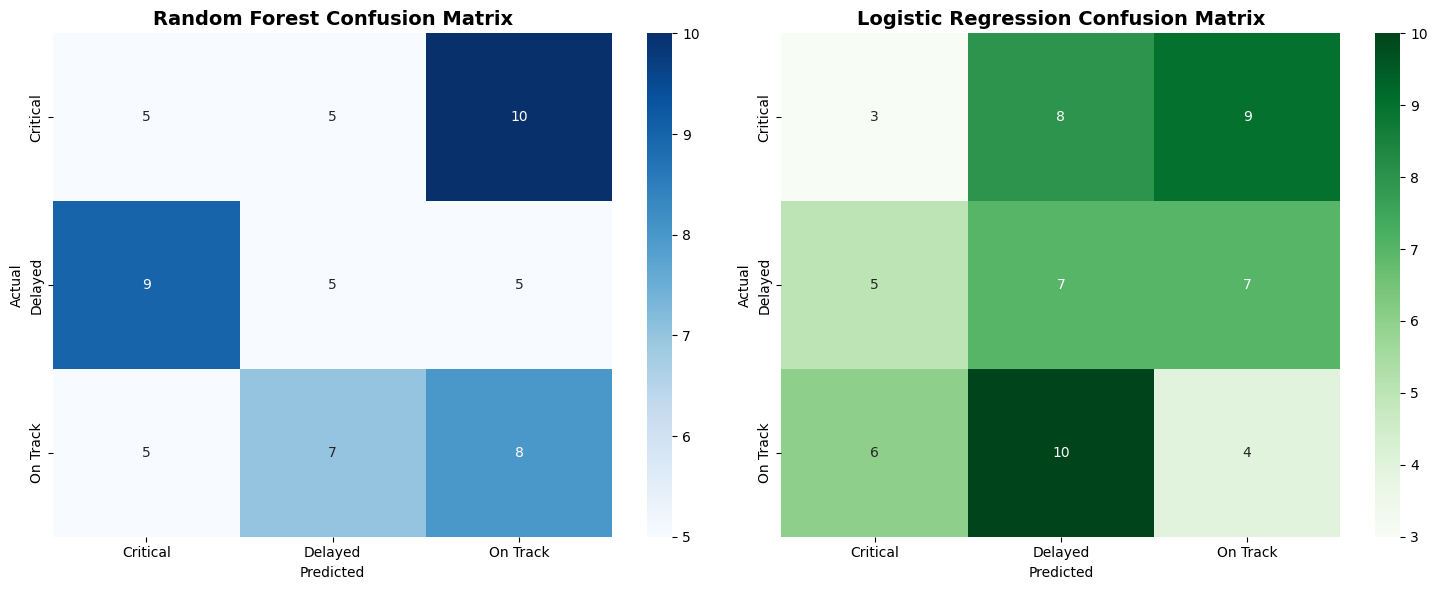


🔑 4. FEATURE IMPORTANCE ANALYSIS
----------------------------------------
Top 10 Most Important Features for Prediction:


,feature,importance
11,OPEX/CAPEX,0.087448
3,Budget ($K),0.082799
12,Forecast Accuracy,0.079365
6,Adoption,0.075455
1,Budget Usage (%),0.075411
0,Team Size,0.058307
4,Sprint Velocity,0.057034
10,Deployment Frequency,0.048254
2,Issues Reported,0.046943
9,Bug Severity Score,0.046206


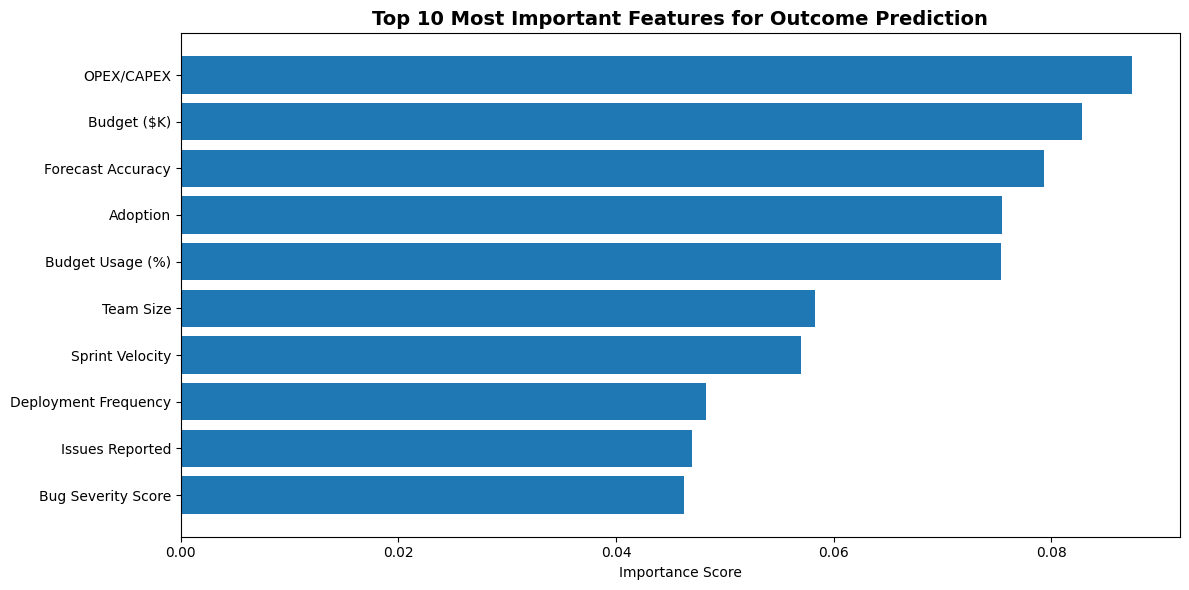

In [ ]:
# VISUALIZE MODEL PERFORMANCE
print("\n📊 3. MODEL PERFORMANCE VISUALIZATION")
print("-" * 40)

# Create confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
ax1.set_title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=lr_model.classes_, yticklabels=lr_model.classes_)
ax2.set_title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature Importance (for Random Forest)
print("\n🔑 4. FEATURE IMPORTANCE ANALYSIS")
print("-" * 40)

feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features for Prediction:")
display(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features for Outcome Prediction',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()

In [ ]:
# MAKING PREDICTIONS ON NEW DATA
print("\n🔮 5. MAKING PREDICTIONS ON NEW PROJECTS")
print("-" * 40)

# Create a sample new project
print("Sample Project Prediction:")

# Find the column order for our model
feature_columns = X_encoded.columns.tolist()

# Create a sample project (using median values from training data)
sample_project = pd.DataFrame({
    'feature': feature_columns,
    'sample_value': [X_train[col].median() if col in X_train.columns else 0
                     for col in feature_columns]
}).set_index('feature')['sample_value']

# Reshape for prediction
sample_project_reshaped = sample_project.values.reshape(1, -1)

# Make prediction
predicted_outcome = rf_model.predict(sample_project_reshaped)
predicted_probabilities = rf_model.predict_proba(sample_project_reshaped)

print(f"\n📋 Sample Project Details:")
print(f"   Features: {len(feature_columns)}")
print(f"   Using median values from training data")

print(f"\n🎯 PREDICTION RESULTS:")
print(f"   Predicted Outcome: {predicted_outcome[0]}")

print(f"\n📊 Confidence Scores:")
for outcome, prob in zip(rf_model.classes_, predicted_probabilities[0]):
    print(f"   • {outcome}: {prob:.1%}")

# Interactive prediction function
print("\n✨ CREATE YOUR OWN PROJECT PREDICTION:")

def predict_project_outcome():
    """
    Interactive function to predict outcome for a custom project
    """
    print("\nEnter project details (or press Enter for default values):")

    # Get user inputs for key features
    inputs = {}

    # Get values for top 5 important features
    top_features = feature_importance.head(5)['feature'].tolist()

    for feature in top_features:
        if feature in X_train.columns:
            default_val = X_train[feature].median()
            try:
                user_val = input(f"{feature} (default: {default_val:.2f}): ")
                inputs[feature] = float(user_val) if user_val else default_val
            except:
                inputs[feature] = default_val

    # Fill missing features with median values
    for col in feature_columns:
        if col not in inputs:
            if col in X_train.columns:
                inputs[col] = X_train[col].median()
            else:
                inputs[col] = 0

    # Create prediction array
    prediction_input = pd.DataFrame([inputs], columns=feature_columns)

    # Make prediction
    outcome = rf_model.predict(prediction_input)[0]
    probabilities = rf_model.predict_proba(prediction_input)[0]

    print(f"\n🎯 PREDICTION: This project is likely to be '{outcome}'")
    print("\n📊 Probability Breakdown:")
    for cls, prob in zip(rf_model.classes_, probabilities):
        print(f"   • {cls}: {prob:.1%}")

    # Add recommendation
    if outcome == 'Critical':
        print("\n⚠️ RECOMMENDATION: High attention needed! Consider:")
        print("   - Increasing team size")
        print("   - Adding budget buffer")
        print("   - Weekly risk reviews")
    elif outcome == 'Delayed':
        print("\n📅 RECOMMENDATION: Timeline risk! Consider:")
        print("   - Re-evaluating deadlines")
        print("   - Prioritizing critical tasks")
        print("   - Daily standups for blockers")
    else:
        print("\n✅ RECOMMENDATION: On track! Keep up:")
        print("   - Current processes")
        print("   - Regular monitoring")
        print("   - Team motivation")

# Uncomment to enable interactive prediction
# predict_project_outcome()


🔮 5. MAKING PREDICTIONS ON NEW PROJECTS
----------------------------------------
Sample Project Prediction:

📋 Sample Project Details:
   Features: 62
   Using median values from training data

🎯 PREDICTION RESULTS:
   Predicted Outcome: Delayed

📊 Confidence Scores:
   • Critical: 32.5%
   • Delayed: 36.5%
   • On Track: 31.0%

✨ CREATE YOUR OWN PROJECT PREDICTION:


AI RECOMMENDATION

In [ ]:
def recommend_action(row):
    if row["Risk Score"] >= 80:
        return "High risk: add buffer, review scope, assign senior resources"
    elif row["Risk Score"] >= 60:
        return "Medium risk: monitor closely, improve planning"
    else:
        return "Low risk: no immediate action required"



In [ ]:
pred_df["Recommended Actions"] = pred_df.apply(recommend_action, axis=1)

pred_df[
    ["Predicted Outcome", "Risk Score", "Recommended Actions"]
].head()


,Predicted Outcome,Risk Score,Recommended Actions
0,Critical,79.5,"Medium risk: monitor closely, improve planning"
1,On Track,59.0,Low risk: no immediate action required
2,On Track,52.5,Low risk: no immediate action required
3,On Track,55.5,Low risk: no immediate action required
4,On Track,57.5,Low risk: no immediate action required


In [ ]:
pred_df[
    ["Predicted Outcome", "Risk Score", "Recommended Actions"]
].to_csv("jira_ai_recommendations.csv", index=False)

print("✅ Saved: jira_ai_recommendations.csv")


✅ Saved: jira_ai_recommendations.csv


In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("✅ model.pkl saved")


✅ model.pkl saved


In [ ]:
from google.colab import files
files.download("model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>